In [9]:
# ==============================================================================
# 🚀 1. HYPERPARAMETER SETTINGS (MODIFIED FOR EXPERIMENTATION)
# ==============================================================================
# Change these values to test Low, Medium, or High configurations:

SETTINGS = {
    # BATCH SIZE: Low=16 | Medium=32 | High=64
    "batch_size": 64,

    # LEARNING RATE: Low=1e-5 | Medium=2e-4 | High=1e-3
    "learning_rate": 1e-3,

    # EPOCHS: Low=5 | Medium=30 | High=100 (EarlyStopping will prevent waste)
    "epochs": 100,

    "img_height": 180,
    "img_width": 180
}

In [10]:
# =========================
# 2️⃣ Imports & Setup
# =========================
import kagglehub
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, GlobalAveragePooling2D, Dense
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [11]:
# =========================
# 3️⃣ Download & Load Dataset
# =========================
path = kagglehub.dataset_download("tongpython/cat-and-dog")
data_root = pathlib.Path(path) / "training_set" / "training_set"

# Load Data using configured Batch Size
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(SETTINGS["img_height"], SETTINGS["img_width"]),
    batch_size=SETTINGS["batch_size"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(SETTINGS["img_height"], SETTINGS["img_width"]),
    batch_size=SETTINGS["batch_size"]
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.


In [12]:
# =========================
# 4️⃣ Data Augmentation
# =========================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(SETTINGS["img_height"], SETTINGS["img_width"], 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Map augmentation to training data
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [14]:
inputs = keras.Input(shape=(SETTINGS["img_height"], SETTINGS["img_width"], 3))
x = inputs

# 5 CNN Blocks (as per original architecture)
for filters, drop in [(32, 0.10), (64, 0.15), (128, 0.20), (256, 0.25), (512, 0.30)]:
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(drop)(x)

# Classifier
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.40)(x)
outputs = Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Apply configured Learning Rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=SETTINGS["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# =========================
# 6️⃣ Callbacks & Training
# =========================
callbacks = [
    ModelCheckpoint("best_cnn_cat_dog.keras", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
]

# Apply configured Epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=SETTINGS["epochs"],
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5601 - loss: 0.8755
Epoch 1: val_loss improved from inf to 0.82027, saving model to best_cnn_cat_dog.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 116s 423ms/step - accuracy: 0.5601 - loss: 0.8744 - val_accuracy: 0.4997 - val_loss: 0.8203 - learning_rate: 0.0010
Epoch 2/100
100/101 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.6003 - loss: 0.6946
Epoch 2: val_loss improved from 0.82027 to 0.70119, saving model to best_cnn_cat_dog.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 25s 248ms/step - accuracy: 0.6005 - loss: 0.6942 - val_accuracy: 0.5503 - val_loss: 0.7012 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6493 - loss: 0.6313
Epoch 3: val_loss did not improve from 0.70119
101/101 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step - accuracy: 0.6494 - loss: 0.6313 - val_accuracy: 0.5434 - val_loss: 0.8258 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6954 -


🏆 BEST MODEL: Val Loss: 0.2951, Val Acc: 88.01%

📊 TRAINING LOG SUMMARY

Epoch 01 | Loss: 0.7695 | Acc: 56.70% | Val Loss: 0.8203 | Val Acc: 49.97%
Epoch 02 | Loss: 0.6784 | Acc: 60.79% | Val Loss: 0.7012 | Val Acc: 55.03%
Epoch 03 | Loss: 0.6271 | Acc: 65.76% | Val Loss: 0.8258 | Val Acc: 54.34%
Epoch 04 | Loss: 0.5882 | Acc: 69.57% | Val Loss: 0.8025 | Val Acc: 49.34%
Epoch 05 | Loss: 0.5755 | Acc: 70.66% | Val Loss: 0.6761 | Val Acc: 63.65%
Epoch 06 | Loss: 0.5586 | Acc: 71.88% | Val Loss: 0.7277 | Val Acc: 62.59%
Epoch 07 | Loss: 0.5405 | Acc: 73.34% | Val Loss: 0.6413 | Val Acc: 67.15%
Epoch 08 | Loss: 0.4913 | Acc: 76.19% | Val Loss: 1.4136 | Val Acc: 51.97%
Epoch 09 | Loss: 0.4754 | Acc: 77.51% | Val Loss: 0.7105 | Val Acc: 65.65%
Epoch 10 | Loss: 0.4370 | Acc: 80.09% | Val Loss: 0.5093 | Val Acc: 75.52%
Epoch 11 | Loss: 0.3981 | Acc: 82.37% | Val Loss: 0.4661 | Val Acc: 76.83%
Epoch 12 | Loss: 0.3746 | Acc: 83.67% | Val Loss: 0.4728 | Val Acc: 77.95%
Epoch 13 | Loss: 0.3502 | 

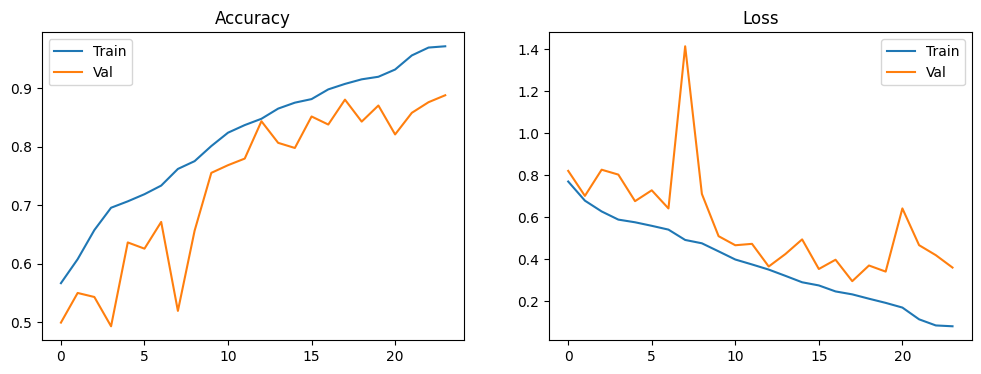

In [16]:
# =========================
# 7️⃣ Evaluation & Metrics
# =========================
best_model = keras.models.load_model("best_cnn_cat_dog.keras")
val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)

print(f"\n🏆 BEST MODEL: Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}")

# Training Log Summary
print("\n📊 TRAINING LOG SUMMARY\n")
for i in range(len(history.history["loss"])):
    print(f"Epoch {i+1:02d} | Loss: {history.history['loss'][i]:.4f} | Acc: {history.history['accuracy'][i]:.2%} | Val Loss: {history.history['val_loss'][i]:.4f} | Val Acc: {history.history['val_accuracy'][i]:.2%}")

# Visualizing results
epochs_range = range(len(history.history["accuracy"]))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(epochs_range, history.history["accuracy"], label='Train'); plt.plot(epochs_range, history.history["val_accuracy"], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(epochs_range, history.history["loss"], label='Train'); plt.plot(epochs_range, history.history["val_loss"], label='Val'); plt.title('Loss'); plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


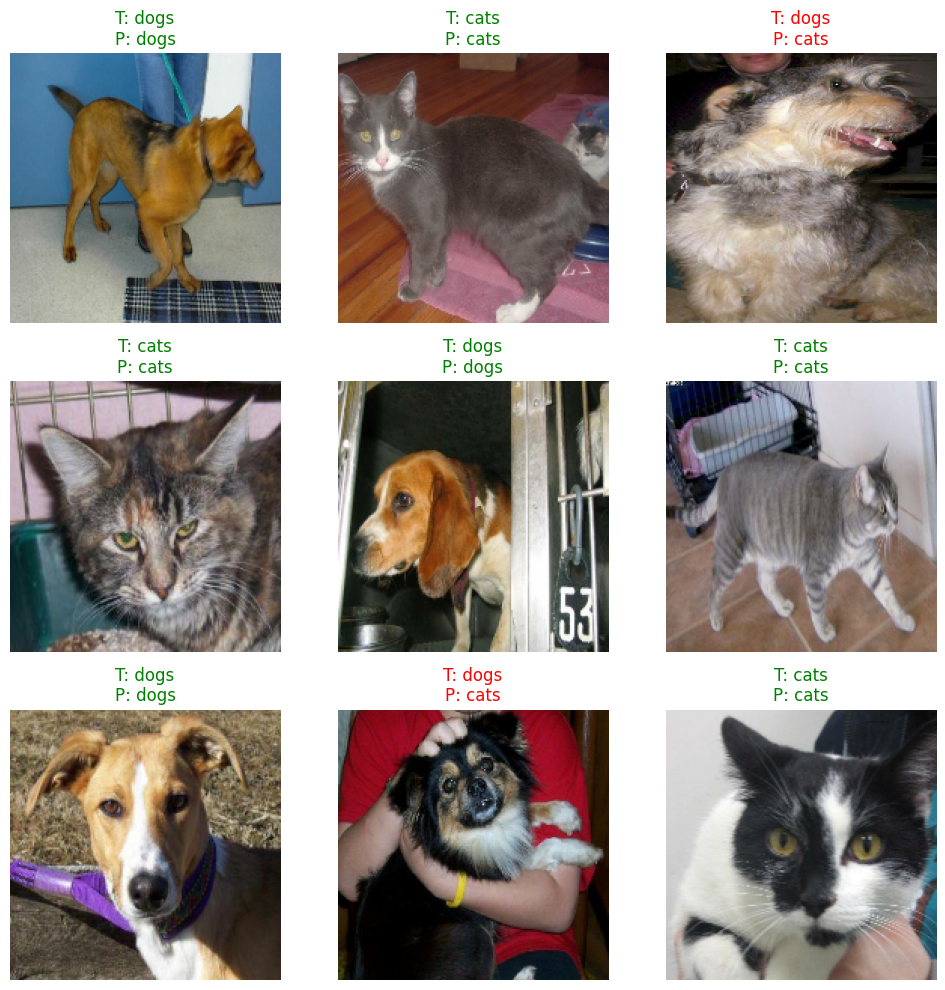

In [18]:
# =========================
# 8️⃣ Validation Predictions
# =========================
for images, labels in val_ds.take(1):
    preds = best_model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    indices = random.sample(range(len(images)), 9)
    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[idx].numpy().astype("uint8"))
        color = "green" if class_names[labels[idx]] == class_names[pred_labels[idx]] else "red"
        plt.title(f"T: {class_names[labels[idx]]}\nP: {class_names[pred_labels[idx]]}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()